In [2]:
import os
from dotenv import load_dotenv

load_dotenv() 
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = os.getenv("LANGSMITH_PROJECT", "ArXiv-Agent-Research")

import pandas as pd
import psycopg2
from IPython.display import display, Markdown
from transformers import AutoTokenizer
from modules.processing import ArticleProcessor
from modules.summarization import SummarizationPipeline, OpenRouterProvider
from modules.agent import ArxivAgent
import json
import re
from tqdm import tqdm
from transformers import AutoTokenizer


db_params = {
    "dbname": os.getenv("DB_NAME", "arxivdb"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD"),
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT", "5433")  
}

selected_model = "qwen/qwen-2.5-7b-instruct" 
def get_tokenizer(model_id):
    return AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

tokenizer = get_tokenizer("Qwen/Qwen2.5-7B-Instruct")
OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")


provider = OpenRouterProvider(
    api_key=OPENROUTER_KEY, 
    model_name=selected_model,
    use_reasoning=False 
)

hub_prompts = {
    "classifier": "fluloeo/arxiv-classifier",
    "rewriter": "fluloeo/arxiv-rewriter",
    "qa": "fluloeo/arxiv-qa",
    "summarization": {
        "map": "fluloeo/arxiv-summarizer-map",
        "reduce": "fluloeo/arxiv-summarizer-reduce"
    }
}

processor = ArticleProcessor(tokenizer)
sum_pipe = SummarizationPipeline(
    provider=provider, 
    tokenizer=tokenizer, 
    prompts=hub_prompts['summarization'], 
    local_prompts=None, 
    use_hub=True
)

agent = ArxivAgent(
    llm_provider=provider,
    retriever=None,      
    sum_pipeline=sum_pipe,
    processor=processor,
    embed_model=None,    
    db_params=db_params, 
    tokenizer=tokenizer,
    prompts=hub_prompts,
    use_critic=False     
)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pulling prompt from LangSmith: fluloeo/arxiv-summarizer-map
Pulling prompt from LangSmith: fluloeo/arxiv-summarizer-reduce
Pulling prompt from LangSmith: fluloeo/arxiv-classifier
Pulling prompt from LangSmith: fluloeo/arxiv-rewriter
Pulling prompt from LangSmith: fluloeo/arxiv-qa


In [3]:
def get_fixed_article_sample(db_params, limit=50):
    with psycopg2.connect(**db_params) as conn:
        query = "SELECT id, title, section_text_new FROM arxivdb.public.articles WHERE section_text_new IS NOT NULL LIMIT %s"
        df = pd.read_sql(query, conn, params=(limit,))
    return df

def save_sample_to_json(df, filename="fixed_articles.json"):
    """Сохраняет DataFrame в JSON с сохранением кодировки (UTF-8)."""
    df.to_json(filename, orient="records", force_ascii=False, indent=2)
    print(f"💾 Выборка ({len(df)} статей) сохранена в файл: {filename}")

def load_sample_from_json(filename="fixed_articles.json"):
    """Загружает выборку из JSON обратно в DataFrame."""
    if os.path.exists(filename):
        df = pd.read_json(filename, orient="records")
        print(f"📦 Выборка загружена из файла: {filename} (статей: {len(df)})")
        return df
    else:
        print(f"⚠️ Файл {filename} не найден!")
        return None

# Пример вызова:
# article_sample = get_fixed_article_sample(db_params, 1)

In [ ]:
# save_sample_to_json(article_sample, 'article_sample.json')
# article_sample = load_sample_from_json('article_sample.json')

💾 Выборка (1 статей) сохранена в файл: article_sample.json
📦 Выборка загружена из файла: article_sample.json (статей: 1)


In [4]:
import ast
def generate_summarization_dataset(
    articles_df: pd.DataFrame, 
    model_name: str, 
    method: str = "map-reduce", # или "full-text"
    output_path: str = "summaries_dataset.json"
):
    """
    Генерирует суммаризации для списка статей и сохраняет в JSON.
    """
    results = []
    
    # Инициализация провайдера для конкретной модели
    current_provider = OpenRouterProvider(api_key=os.getenv("OPENROUTER_API_KEY"), model_name=model_name)
    
    # Настройка пайплайна суммаризации (для Map-Reduce)
    sum_pipe = SummarizationPipeline(
        provider=current_provider, 
        tokenizer=tokenizer, 
        prompts=hub_prompts['summarization']
    )
    
    # Инициализация агента (только для метода map-reduce)
    temp_agent = ArxivAgent(
        llm_provider=current_provider,
        retriever=None, sum_pipeline=sum_pipe, processor=processor,
        embed_model=None, db_params=db_params, tokenizer=tokenizer, prompts=hub_prompts
    )

    full_text_prompt = """You are the Chief Scientific Editor of a prestigious peer-reviewed journal. Your task is to perform a comprehensive analysis of a full scientific paper and synthesize it into a high-level, dense analytical report.

YOUR OBJECTIVES:
1. SYNTHESIS: Extract and integrate the most critical findings from the entire text. Distinguish between the authors' primary claims and secondary observations.
2. COHERENCE & FLOW: Transform raw academic data into a single, fluid narrative. Avoid repetitive statements often found across the Abstract, Introduction, and Conclusion of the original paper.
3. TERMINOLOGY: Utilize rigorous academic English and standard technical nomenclature. Ensure the language is precise and appropriate for a professional scientific audience.
4. FACTUAL INTEGRITY: Strictly adhere to the provided text. Do not introduce external information or "hallucinations." If the paper lacks specific quantitative data for a section, provide a high-quality qualitative assessment based on the text.
5. MATHEMATICAL PRECISION: Use LaTeX (enclosed in $ symbols) for all variables, parameters, and essential formulas. Only include equations that define the core novelty or methodology of the work.

STYLE REQUIREMENTS:
- Tone: Formal, objective, and dry.
- Density: Maximum information density with zero "filler" words.
- Grammar: No personal pronouns (e.g., "I," "we," "the authors") and no introductory conversational phrases.
FULL SCIENTIFIC PAPER TEXT:
---
{text}
---

INSTRUCTION:
Analyze the provided paper and synthesize a final analytical report of 400–600 words. Your goal is to capture the essence of the research with the precision of a high-impact journal editorial.

REPORT STRUCTURE:
1. **Research Objective**: Define the underlying scientific problem, the authors' primary motivation, and the specific research questions or goals addressed.
2. **Methodology**: Detail the proposed framework, experimental setup, technical stack, and any algorithmic or theoretical innovations. Focus on the "how" of the research.
3. **Results and Analysis**: Synthesize the key quantitative metrics (e.g., accuracy, p-values, SOTA comparisons, efficiency gains). Interpret the most significant trends and findings.
4. **Conclusion and Significance**: Summarize the scientific contribution, the impact on the field, and potential real-world or theoretical applications.

The report must be written in English.
\n\nIMPORTANT: Start your response IMMEDIATELY with the report. Do NOT include any 'Analyzing the task', 'Thinking process', or introductory meta-comments. Start directly with '1. **Research Objective**'."""

    print(f"🚀 Генерация датасета ({method}) с использованием {model_name}...")

    for _, row in tqdm(articles_df.iterrows(), total=len(articles_df)):
        aid, title, raw_sections = row['id'], row['title'], row['section_text_new']
        
        try:
            if method == "map-reduce":
                # Используем ноду агента
                state = {
                    "query": "Сделай обзор", "intent": "summarize",
                    "relevant_docs": pd.DataFrame([{"article_id": aid}]),
                    "search_queries": [], "article_chunks": {}, "final_answer": "",
                    "debug_data": {}, "critic_notes": []
                }
                res = temp_agent.summarization_node(state)
                summary = res["final_answer"]
            
            else:
                # Метод Full-Text (конкатенация)
                if isinstance(raw_sections, str):
                    try:
                        sections_dict = json.loads(raw_sections)
                    except json.JSONDecodeError:
                        try:
                            # ast.literal_eval безопасно обрабатывает одинарные кавычки Python
                            sections_dict = ast.literal_eval(raw_sections)
                        except Exception:
                            # Если это просто текст, а не словарь
                            sections_dict = {"Main Content": raw_sections}
                else:
                    sections_dict = raw_sections if raw_sections else {"Content": "No text"}
                combined_text = "\n\n".join([f"## {k}\n{v}" for k, v in sections_dict.items()])
                
                prompt = full_text_prompt.format(text=combined_text) 
                summary = current_provider.generate([prompt], {"temperature": 0, "max_tokens": 4096})[0]

            results.append({
                "article_id": aid,
                "title": title,
                "source_text": raw_sections, # Сохраняем для судьи
                "generated_summary": summary,
                "model_used": model_name,
                "method": method
            })

        except Exception as e:
            print(f"Ошибка на статье {aid}: {e}")

    # Сохранение
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    
    print(f"Датасет сохранен в {output_path}")
    return results

In [28]:
# generate_summarization_dataset(
#     articles_df=article_sample,
#     model_name="qwen/qwen-2.5-7b-instruct",
#     method="map-reduce",
#     output_path="exp1_7b_mapreduce.json"
# )

# # 3. Эксперимент №2: Модель 7B, метод Full-Text
# generate_summarization_dataset(
#     articles_df=article_sample,
#     model_name="qwen/qwen-2.5-7b-instruct",
#     method="full-text",
#     output_path="exp2_7b_fulltext.json"
# )

In [14]:
from deepeval.models.base_model import DeepEvalBaseLLM
from deepeval.metrics import GEval, SummarizationMetric
from deepeval.test_case import LLMTestCase, LLMTestCaseParams

class OpenRouterDeepEvalModel(DeepEvalBaseLLM):
    def __init__(self, provider, model_name, debug: bool = False):
        self.provider = provider
        self.model_name = model_name
        self.debug = debug

    def load_model(self):
        return self.provider

    def generate(self, prompt: str) -> str:
        raw_res = self.provider.generate([prompt], {"temperature": 0, "max_tokens": 4096})[0]
        
        # 1. Удаляем блоки мыслей <think>
        cleaned = re.sub(r'<think>.*?</think>', '', raw_res, flags=re.DOTALL).strip()
        
        # 2. Пытаемся найти JSON-подобную структуру
        match = re.search(r'(\{.*\})', cleaned, re.DOTALL)
        if not match:
             return '{"score": 0, "reason": "No JSON block found in response"}'
             
        json_str = match.group(1)
        
        # --- СТРАТЕГИЯ ОЧИСТКИ LaTeX ---
        # 3. Экранируем все бэкслеши ( превращаем \ в \\ )
        # Это сделает \sigma -> \\sigma, что валидно для JSON
        json_str = json_str.replace('\\', '\\\\')
        
        # 4. НО! Мы только что сломали валидные последовательности типа \\n или \\"
        # Возвращаем их в нормальное состояние
        for char in ['"', 'n', 't', 'r', 'b', 'f', '/', 'u']:
            json_str = json_str.replace(f'\\\\{char}', f'\\{char}')
            
        # 5. Удаляем физические переносы строк внутри JSON, которые не экранированы
        json_str = json_str.replace('\n', ' ').replace('\t', ' ')

        try:
            # Проверяем на валидность
            json.loads(json_str)
            return json_str
        except Exception as e:
            # --- ПЛАН "Б": Если JSON всё еще битый, вытаскиваем Score через Regex ---
            print(f"⚠️ JSON parsing failed for an article. Switching to Regex fallback. Error: {e}")
            score_match = re.search(r'"score":\s*([\d\.]+)', cleaned)
            reason_match = re.search(r'"reason":\s*"(.*?)"', cleaned, re.DOTALL)
            
            score = score_match.group(1) if score_match else 0
            reason = reason_match.group(1).replace('\n', ' ') if reason_match else "Failed to parse reason"
            
            return f'{{"score": {score}, "reason": "{reason} (Regex Fallback)"}}'

    async def a_generate(self, prompt: str) -> str:
        return self.generate(prompt)

    def get_model_name(self):
        return self.model_name


from deepeval.test_case import LLMTestCase, LLMTestCaseParams


/var/folders/5w/td1qssr102g_shnry7z0q4k00000gn/T/ipykernel_65048/3959808130.py:3: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Use 'SingleTurnParams' instead.
  from deepeval.test_case import LLMTestCase, LLMTestCaseParams
/var/folders/5w/td1qssr102g_shnry7z0q4k00000gn/T/ipykernel_65048/3959808130.py:3: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Use 'SingleTurnParams' instead.
  from deepeval.test_case import LLMTestCase, LLMTestCaseParams
/var/folders/5w/td1qssr102g_shnry7z0q4k00000gn/T/ipykernel_65048/3959808130.py:62: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Use 'SingleTurnParams' instead.
  from deepeval.test_case import LLMTestCase, LLMTestCaseParams
/var/folders/5w/td1qssr102g_shnry7z0q4k00000gn/T/ipykernel_65048/3959808130.py:62: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Us

In [6]:
def run_full_evaluation_pipeline(
    candidate_json_path: str, 
    gold_json_path: str, 
    judge_model: str = "qwen/qwen3-235b-a22b-2507",
    output_path: str = "final_eval_results.json"
):
    """
    Единый пайплайн оценки:
    1. Faithfulness (vs Input) - отсутствие галлюцинаций.
    2. Alignment (vs Gold) - сходство ключевых научных смыслов с Gemini.
    3. Summarization (vs Gold) - чек-лист по методологии и выводам.
    """
    
    # 1. Загрузка данных
    with open(candidate_json_path, "r", encoding="utf-8") as f:
        candidates = {item['article_id']: item for item in json.load(f)}
    
    with open(gold_json_path, "r", encoding="utf-8") as f:
        golds = {item['article_id']: item for item in json.load(f)}

    # 2. Инициализация судьи
    judge_provider = OpenRouterProvider(api_key=os.getenv("OPENROUTER_API_KEY"), model_name=judge_model)
    deepeval_judge = OpenRouterDeepEvalModel(judge_provider, judge_model)

    # --- МЕТРИКА 1: FAITHFULNESS (G-Eval) ---
    # Проверка: не придумала ли модель чего-то, чего нет в оригинале
    faithfulness_metric = GEval(
        name="Scientific Faithfulness",
        criteria="""
        Evaluate the factual consistency of the 'Actual Output' against the 'Input'.
        Check if every scientific claim, metric, and conclusion in the summary is explicitly supported by the source text.
        Penalize heavily for hallucinations, overstatements, or misinterpretation of technical data.
        """,
        evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT],
        model=deepeval_judge
    )

    # --- МЕТРИКА 2: SUMMARY ALIGNMENT (G-Eval) ---
    # Проверка: насколько суммаризация похожа на "идеальную" от Gemini
    alignment_metric = GEval(
        name="Gold Standard Alignment",
        criteria="""
        Compare the 'Actual Output' with the 'Expected Output' (Gold Standard).
        Assess how well the candidate captured the primary scientific contributions, novelty, and methodology identified by the expert model.
        The score should reflect the coverage of essential insights. Mark down for missing key findings that the Gold Standard highlighted.
        """,
        evaluation_params=[LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.EXPECTED_OUTPUT],
        model=deepeval_judge
    )

    # --- МЕТРИКА 3: SUMMARIZATION METRIC (DeepEval Built-in) ---
    # Структурный анализ соответствия эталону
    summarization_metric = SummarizationMetric(
        threshold=0.5,
        model=deepeval_judge,
        assessment_questions=[
            "Does the actual summary cover the same core methodology as the reference summary?",
            "Are the primary quantitative results or performance metrics consistent with the reference?",
            "Does the actual summary capture the specific scientific novelty or 'contribution' mentioned in the reference?",
            "Is the actual summary free from contradictory statements when compared to the reference?",
            "Does the summary maintain a professional scientific tone suitable for research dissemination?"
        ]
    )

    results = []
    print(f"🔬 Starting Evaluation: {len(candidates)} articles | Judge: {judge_model}")

    for aid, cand_item in tqdm(candidates.items()):
        if aid not in golds:
            print(f"⚠️ Skip {aid}: No gold reference found.")
            continue
            
        gold_item = golds[aid]
        source_text = cand_item['source_text']
        
        # Подготовка текста (если это словарь разделов)
        if isinstance(source_text, dict):
            source_text = "\n\n".join([f"## {k}\n{v}" for k, v in source_text.items()])

        # Создаем универсальный тест-кейс
        test_case = LLMTestCase(
            input=str(source_text),
            actual_output=cand_item['generated_summary'],
            expected_output=gold_item['generated_summary']
        )

        try:
            # Запуск измерений
            faithfulness_metric.measure(test_case)
            alignment_metric.measure(test_case)
            summarization_metric.measure(test_case)

            results.append({
                "article_id": aid,
                "title": cand_item['title'],
                "scores": {
                    "faithfulness": faithfulness_metric.score,
                    "alignment_vs_gold": alignment_metric.score,
                    "summarization_factuality": summarization_metric.score
                },
                "reasons": {
                    "faithfulness": faithfulness_metric.reason,
                    "alignment": alignment_metric.reason,
                    "summarization": summarization_metric.reason
                },
                "candidate_summary": cand_item['generated_summary'],
                "gold_summary": gold_item['generated_summary']
            })
        except Exception as e:
            print(f"❌ Error evaluating {aid}: {e}")

    # 3. Сохранение и вывод итогов
    df_eval = pd.DataFrame(results)
    
    # Разворачиваем словари со скорами для удобства анализа
    scores_df = pd.json_normalize(df_eval['scores'])
    final_df = pd.concat([df_eval.drop(['scores'], axis=1), scores_df], axis=1)
    
    final_df.to_json(output_path, orient="records", force_ascii=False, indent=2)
    
    print("\n" + "="*30)
    print("       FINAL RESULTS       ")
    print("="*30)
    print(f"Mean Faithfulness: {final_df['faithfulness'].mean():.2f}")
    print(f"Mean Gold Alignment: {final_df['alignment_vs_gold'].mean():.2f}")
    print(f"Mean Factuality (Built-in): {final_df['summarization_factuality'].mean():.2f}")
    print(f"Results saved to: {output_path}")
    
    return final_df

In [7]:
# gold_file = "dataset_gemini.json"
# if not os.path.exists(gold_file):
#     generate_summarization_dataset(
#         articles_df=article_sample,
#         model_name="google/gemini-2.5-pro", 
#         method="full-text",
#         output_path=gold_file
#     )
# else:
#     print(f"dataset already exists: {gold_file}")

In [7]:
dataset_gemini = load_sample_from_json('dataset_gemini_final.json')

📦 Выборка загружена из файла: dataset_gemini_final.json (статей: 50)


In [8]:
article_sample = load_sample_from_json('article_sample.json')

📦 Выборка загружена из файла: article_sample.json (статей: 50)


In [9]:
dataset_qwen = load_sample_from_json('dataset_candidate_qwen7b.json')

📦 Выборка загружена из файла: dataset_candidate_qwen7b.json (статей: 50)


In [ ]:

# print("\n--- Generating Candidate Summaries (Qwen 7B Map-Reduce) ---")
# candidate_file = "dataset_candidate_qwen7b.json"
# if not os.path.exists(candidate_file):
#     generate_summarization_dataset(
#         articles_df=article_sample,
#         model_name="qwen/qwen-2.5-7b-instruct", 
#         method="map-reduce", 
#         output_path=candidate_file
#     )
# else:
#     print(f"Candidate dataset already exists: {candidate_file}")




--- Generating Candidate Summaries (Qwen 7B Map-Reduce) ---
Pulling prompt from LangSmith: fluloeo/arxiv-summarizer-map
Pulling prompt from LangSmith: fluloeo/arxiv-summarizer-reduce
Pulling prompt from LangSmith: fluloeo/arxiv-classifier
Pulling prompt from LangSmith: fluloeo/arxiv-rewriter
Pulling prompt from LangSmith: fluloeo/arxiv-qa
🚀 Генерация датасета (map-reduce) с использованием qwen/qwen-2.5-7b-instruct...


  0%|          | 0/50 [00:00<?, ?it/s]

[DEBUG] Parsed sections: ['INTRODUCTION', 'BACKGROUND', 'Keyword Analysis', 'User Taxonomy', 'Generating Recommendations', 'Item Popularity Ranking', 'Mining Interests from Keywords', 'Discovering Potential Interests', 'Grading Function', 'TRAINING', 'Training Result', 'Prediction and Precision Evaluation', 'Improvements of the System', 'CONCLUSION AND FUTURE WORK']

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781654291-4PCwghAsctpdg5xQPDkV', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="- Online social networking services like Twitter have been tremendously popular, with a considerable speed of user growth.\n- Thousands of new registrations are observed everyday in dominant platforms like Sina and Tencent Microblog since the introduction of microblog -Chinese twitter -in 2007.\n- Celebrities and organizations also register microblog, which leads to diversity of topics and helps attract more potential users.\n- 

  2%|▏         | 1/50 [01:09<56:58, 69.77s/it]


[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781654350-cLv3EXh9SQhBiVlyoMKo', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="### Research Objective\n\nThe study aims to address the challenges of user recommendation in Tencent Microblog, a popular microblogging platform in China. The primary motivation stems from the rapid growth of user registrations and the subsequent information overload, which can lead to user dissatisfaction and attrition. The authors propose a hybrid recommender system to overcome the limitations of existing methods, such as content-based, collaborative filtering, and influential ranking algorithms. The specific goals include enhancing the precision and stability of recommendations by integrating keyword analysis, user taxonomy, and preference extraction techniques.\n\n### Methodology\n\nThe hybrid recommender system is designed to generate ordered item lists by mining data from Tencent Micr

...


[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781659123-kXCTbHzV3DZUt1EUmYtY', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="### Research Objective\n\nThe primary objective of this study is to address the challenges associated with generating long videos using diffusion models (DMs). Specifically, the authors aim to enhance the temporal coherence and visual fidelity of long videos generated by video diffusion models (VDMs) without requiring additional training or significant computational resources. The motivation stems from the limitations of existing VDMs, which are often constrained by their ability to generate videos of only a few seconds in length due to insufficient data scale and computational resources. The study proposes GLC-Diffusion, a novel tuning-free method that integrates a dual-path Global-Local Collaborative Denoising (GLCD) mechanism, a Noise Reinitialization strategy, and a Video Motion Consist

 98%|█████████▊| 49/50 [1:23:58<02:10, 130.21s/it]


[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781659322-cY9Ck3Kgb1QWEhcm5vqw', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="### Research Objective\n\nThe primary objective of this study is to formalize and explore the concept of query repairs in the context of database management. Specifically, the authors aim to define and analyze different types of query repairs, including generalizations, specializations, and repairs themselves, using various proximity pre-orders. The motivation stems from the need to address inconsistencies in database queries, where the results may include undesired tuples or missing desired tuples. The study seeks to develop a framework that allows users to adjust their queries to better align with their expectations by finding minimal changes that fit a given set of labeled examples.\n\n### Methodology\n\nThe authors propose a rigorous framework for defining query repairs based on proximi

100%|██████████| 50/50 [1:25:56<00:00, 103.13s/it]


[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781659436-bKDPPgm5gEHRnIm6x5ID', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="### Research Objective\n\nThe primary objective of this study was to develop an autonomous robotic system for terrestrial laser scanning (TLS) based field phenotyping. The authors aimed to address the limitations of traditional manual and labor-intensive methods by integrating a high-resolution 3D LiDAR with a ground robot for autonomous data collection. Specifically, the study sought to achieve the following goals:\n1. Integrate a high-resolution 3D LiDAR with a ground robot for autonomous data collection in the field.\n2. Develop a computer-based approach to optimize the distribution of scan locations for TLS site planning.\n3. Implement an optimal route planning algorithm for efficient field navigation between scan locations.\n4. Conduct field experiments to evaluate the system's perform

In [11]:
def calculate_dataset_faithfulness(
    json_path: str, 
    judge_model: str = "qwen/qwen3-235b-a22b-2507",
    output_path: str = None
):
    """
    Считает ТОЛЬКО верность (Faithfulness) относительно первоисточника.
    Идеально для Sanity Check 'Золотого стандарта' и оценки Кандидата.
    """
    
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    judge_provider = OpenRouterProvider(api_key=os.getenv("OPENROUTER_API_KEY"), model_name=judge_model)
    deepeval_judge = OpenRouterDeepEvalModel(judge_provider, judge_model)

    faithfulness_metric = GEval(
        name="Scientific Faithfulness",
        criteria="""
    Evaluate the 'Actual Output' for scientific integrity and factual alignment with the 'Input'.
    
    1. Quantitative Fidelity: All numerical values, statistical metrics (p-values, R²), and units of measurement must be identical to the source.
    2. Technical Notations: Validate the correct context of LaTeX formulas ($...$) and complexity classes (e.g., P-space, NP-hard). Do not treat them as hallucinations if they exist in the source.
    3. Factual Logic: Verify that methodological claims and causal relationships (e.g., 'A improves B') are directly supported. Penalize overgeneralizations.
    
    Scoring Guideline:
    - 1.0 (Excellent): Perfect factual alignment. Technical and numerical details are precise.
    - 0.8 (Good): Factually correct, but omits minor technical constraints or specific parameters.
    - 0.5 (Fair): Contains one distinct factual contradiction or significant numerical error.
    - 0.0 (Poor): Major hallucinations, inverted results, or claims entirely absent from the source.
    """,
        evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT],
        model=deepeval_judge
    )

    results = []
    print(f"🧐 Evaluating Faithfulness for: {json_path}")

    for item in tqdm(data):
        source_text = item['source_text']
        # Если в JSON хранится словарь разделов, склеиваем его
        if isinstance(source_text, dict):
            source_text = "\n\n".join([f"## {k}\n{v}" for k, v in source_text.items()])
        
        test_case = LLMTestCase(
            input=str(source_text),
            actual_output=item['generated_summary']
        )

        try:
            faithfulness_metric.measure(test_case)
            results.append({
                "article_id": item['article_id'],
                "title": item['title'],
                "faithfulness_score": faithfulness_metric.score,
                "reason": faithfulness_metric.reason
            })
        except Exception as e:
            print(f"❌ Error at {item['article_id']}: {e}")

    # 4. Итоги
    df_results = pd.DataFrame(results)
    mean_score = df_results['faithfulness_score'].mean()
    
    if output_path:
        df_results.to_json(output_path, orient="records", force_ascii=False, indent=2)
    
    print(f"\n✅ Finished {json_path}")
    print(f"📊 Mean Faithfulness Score: {mean_score:.4f}")
    
    return df_results




In [12]:
gemini_faith = calculate_dataset_faithfulness(
    "dataset_gemini_final.json", 
    output_path="audit_gemini_faith_2.json"
)

# 2. Проверяем Qwen (Ваш агент)
# qwen_faith = calculate_dataset_faithfulness(
#     "dataset_candidate_qwen7b.json", 
#     output_path="audit_qwen_faith.json"
# )

🧐 Evaluating Faithfulness for: dataset_gemini_final.json


  0%|          | 0/50 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781683570-YKOHUEAFLrgYXYxngL7q', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n    "steps": [\n        "Verify that all numerical values,
statistical metrics (e.g., p-values, R²), and units in the Actual Output exactly match those in the Input, ensuring
Quantitative Fidelity.",\n        "Check that technical notations such as LaTeX formulas ($...$) and complexity 
classes (e.g., NP-hard, P-space) in the Actual Output are present and used in the same context as in the Input.",\n
"Assess whether methodological claims and causal relationships (e.g., \'A improves B\') in the Actual Output are 
explicitly supported by the Input, avoiding overgeneralizations or unsupported assertions.",\n        "Compare the 
Actual Output against the Input for any factual contradictions, hallucinated content, or inverted results, and 
assign a score based on the Scoring Guideline."\n    ]\n}', refusal=None, role='assistant', annotations=None, 
audio=None, function_call=None, tool_calls=None), native_finish_reason='stop')], created=1781683570, 
model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', service_tier=None, system_fingerprint=None, 
usage=CompletionUsage(completion_tokens=166, prompt_tokens=341, total_tokens=507, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=0.00012697, is_byok=False, cost_details={'upstream_inference_cost': 0.00012697, 
'upstream_inference_prompt_cost': 3.069e-05, 'upstream_inference_completions_cost': 9.628e-05}), provider='Novita')

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781683574-0OaHxJh40BWUpLHKMyfg', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n    "reason": "The response aligns closely with the input 
in structure and content, accurately reflecting key technical components such as the user taxonomy (active, 
inactive, fake), the grading function with learned weights α₁ and α₂, and the use of indirect collaborative 
filtering with familiarity function fami(uj, uk). It correctly reports numerical results from the input: MAP@3 
values for active (0.411), inactive (0.469), and fake (0.336) users, as well as the training parameters ωi = 1/3 
and β = 0.9. The LaTeX notation $grade(u_j, i_k) = \\\\alpha_1 \\\\cdot hot_k + \\\\alpha_2 \\\\cdot sim(u_j, i_k)$
is properly rendered and contextually accurate. Methodological claims—such as the higher influence of popularity on
active users versus interest similarity on inactive users—are directly supported by the training results in the 
input. No hallucinations or factual contradictions are present, and all causal relationships are grounded in the 
provided text. Quantitative fidelity, technical notation, and methodological support are fully maintained.",\n    
"score": 10\n}', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, 
tool_calls=None), native_finish_reason='stop')], created=1781683574, model='qwen/qwen3-235b-a22b-07-25', 
object='chat.completion', service_tier=None, system_fingerprint=None, usage=CompletionUsage(completion_tokens=245, 
prompt_tokens=5465, total_tokens=5710, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=0.0009635275, is_byok=False, cost_details={'upstream_inference_cost': 0.0009635275, 
'upstream_inference_prompt_cost': 0.0008170175, 'upstream_inference_completions_cost': 0.00014651}), 
provider='Alibaba')

...

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781684104-jTWrftzpgidBns4bRpIN', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n  "reason": "The Actual Output accurately reflects the 
Input\'s research objective, methodology, and results, maintaining quantitative fidelity by correctly referencing 
key parameters (e.g., α₁, β₁), methods (e.g., split4, if4), and performance outcomes. It properly uses technical 
notations like LaTeX for equations ($e^{\\\\tau K}$) and correctly describes the Kronecker-sum structure and 
tensor-based computations. Methodological claims are well-supported: it correctly states that split4 is most 
efficient for cubic nonlinearities with analytical solutions, while if4 outperforms for cubic-quintic and coupled 
cases where nonlinear flows require numerical approximation. No factual contradictions or hallucinations are 
present, and all causal relationships (e.g., efficiency depending on nonlinearity complexity) are directly backed 
by the Input. The summary is concise and aligned with the evaluation steps.",\n  "score": 10\n}', refusal=None, 
role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None), 
native_finish_reason='stop')], created=1781684104, model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', 
service_tier=None, system_fingerprint=None, usage=CompletionUsage(completion_tokens=184, prompt_tokens=10431, 
total_tokens=10615, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, 
audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=0.00104551, is_byok=False, cost_details={'upstream_inference_cost': 0.00104551, 
'upstream_inference_prompt_cost': 0.00093879, 'upstream_inference_completions_cost': 0.00010672}), 
provider='Novita')

 98%|█████████▊| 49/50 [09:02<00:09,  9.48s/it]

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781684112-oUyrSRv0bGOpZSbGsAjA', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n    "reason": "The Actual Output demonstrates strong 
alignment with the Input across all evaluation steps. It accurately preserves all key numerical values (e.g., 
85–90% reduction in scan locations, 134.5 m vs. 146 m travel distance, 0.565 cm and 0.376 cm location errors, 
Hausdorff distance of 1.25 cm), statistical metrics, and units. Technical notations such as the LaTeX-formatted TSP
objective function $\\\\min \\\\sum_{i,j} w_{ij}x_{ij}$ and complexity-related concepts like the Traveling Salesman
Problem and greedy algorithm are correctly used in context. Methodological claims—such as the use of slab-based ray
casting, visibility analysis via voxel discretization, and sensor fusion via Extended Kalman Filter—are explicitly 
supported by the Input. There are no factual contradictions, hallucinations, or inverted results; causal 
relationships (e.g., C2C registration improving alignment from 27.3 cm to ~2 cm) are faithfully represented. The 
summary is comprehensive, precise, and maintains quantitative and conceptual fidelity.",\n    "score": 10\n}', 
refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None), 
native_finish_reason='stop')], created=1781684112, model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', 
service_tier=None, system_fingerprint=None, usage=CompletionUsage(completion_tokens=248, prompt_tokens=17678, 
total_tokens=17926, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, 
audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=5, cache_write_tokens=0, video_tokens=0), 
cost=0.0039207, is_byok=False, cost_details={'upstream_inference_cost': 0.0039207, 
'upstream_inference_prompt_cost': 0.00371238, 'upstream_inference_completions_cost': 0.00020832}), 
provider='StreamLake')

100%|██████████| 50/50 [09:10<00:00, 11.02s/it]


✅ Finished dataset_gemini_final.json
📊 Mean Faithfulness Score: 0.8200


In [ ]:


# print("\n--- Running Evaluation Pipeline ---")
# # В качестве судьи используем самую мощную модель (Qwen 235B или GPT-4o)
# df_results = run_full_evaluation_pipeline(
#     candidate_json_path=candidate_file,
#     gold_json_path=gold_file,
#     judge_model="qwen/qwen3-235b-a22b-2507",
#     output_path="experiment_results_qwen7b_vs_gemini.json"
# )

# # --- ШАГ 5: Анализ результатов ---
# print("\n--- Top 3 Best Aligned Summaries ---")
# display(df_results.sort_values(by="alignment_vs_gold", ascending=False)[["title", "alignment_vs_gold", "faithfulness"]].head(3))

# print("\n--- Top 3 Worst (Need to check for hallucinations) ---")
# display(df_results.sort_values(by="faithfulness", ascending=True)[["title", "faithfulness", "reasons"]].head(3))

# # Посмотрим детальную причину низкой оценки для первой статьи в списке плохих
# if not df_results.empty:
#     worst_article = df_results.sort_values(by="faithfulness").iloc[0]
#     print(f"\n🔍 Анализ ошибки для: {worst_article['title']}")
#     print(f"Reason: {worst_article['reasons']['faithfulness']}")

⚖️ Начало оценки датасета exp1_7b_mapreduce.json судьей qwen/qwen3-235b-a22b-2507...


  0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781642570-ooJt9kRbOlX4B1YP1hSj', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n    "steps": [\n        "Read the Input carefully to 
identify all explicitly stated facts.",\n        "Compare each statement in the Actual Output to the Input to 
verify it is directly supported.",\n        "Identify any information in the Actual Output that is not present or 
inferable from the Input—these are hallucinations.",\n        "Deduct points for each hallucination; only factual, 
input-supported content should remain in the summary."\n    ]\n}', refusal=None, role='assistant', 
annotations=None, audio=None, function_call=None, tool_calls=None, reasoning=None), native_finish_reason='stop')], 
created=1781642570, model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', service_tier=None, 
system_fingerprint='vllm-0.20.2rc1.dev1068+g628499d4f-tp4-ep-f114626d', usage=CompletionUsage(completion_tokens=90,
prompt_tokens=134, total_tokens=224, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=9.076e-05, is_byok=False, cost_details={'upstream_inference_cost': 9.076e-05, 
'upstream_inference_prompt_cost': 1.876e-05, 'upstream_inference_completions_cost': 7.2e-05}), provider='Parasail')

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781642573-5xmCDp7rekJAjerwkPUA', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n  "reason": "The Actual Output contains multiple 
hallucinations and inaccuracies. It incorrectly states that η(0) = 0 and λ(0) = ∞, while the Input specifies η(0) =
η₀ ∈ [0,1] and λ(0) = λ₀ ∈ (1, +∞), with π₀ being a Gaussian or efficiently samplable distribution. The Output 
misrepresents the interpolation curve, claiming π_θ = η(θ) exp(−1/(2λ(θ)) V(x)), which does not match the Input\'s 
definition in Eq. (5). It falsely attributes T = A/(4ε²) to Theorem 2, while this bound is from Theorem 1 for ALD, 
not ALMC. The complexity claim O(dβ²A²ε⁶) misquotes Theorem 2, which includes additional dependencies and is not 
simplified as stated. The Output also introduces unsupported claims about the method\'s applicability and 
advantages without grounding in the Input. These unverified and incorrect details significantly deviate from the 
source.",\n  "score": 2\n}', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, 
tool_calls=None, reasoning=None), native_finish_reason='stop')], created=1781642573, 
model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', service_tier=None, system_fingerprint=None, 
usage=CompletionUsage(completion_tokens=238, prompt_tokens=9986, total_tokens=10224, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=0.00092254, is_byok=False, cost_details={'upstream_inference_cost': 0.00092254, 
'upstream_inference_prompt_cost': 0.00089874, 'upstream_inference_completions_cost': 2.38e-05}), 
provider='DeepInfra')

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781642633-z74lRVlfgMPutN4V9dr8', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n    "steps": [\n        "Identify the key scientific 
findings and methodology described in the Input.",\n        "Compare the Actual Output to the Input, checking if it
includes the key scientific findings and methodology.",\n        "Verify that the Actual Output omits trivial or 
irrelevant details present in the Input.",\n        "Assess whether the summary in the Actual Output is concise and
accurately reflects the core content of the Input."\n    ]\n}', refusal=None, role='assistant', annotations=None, 
audio=None, function_call=None, tool_calls=None, reasoning=None), native_finish_reason='stop')], 
created=1781642633, model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', service_tier=None, 
system_fingerprint=None, usage=CompletionUsage(completion_tokens=87, prompt_tokens=132, total_tokens=219, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=2.19e-05, is_byok=False, cost_details={'upstream_inference_cost': 2.19e-05, 'upstream_inference_prompt_cost': 
1.32e-05, 'upstream_inference_completions_cost': 8.7e-06}), provider='WandB')

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781642634-vhyP4LN4u5DcIC9sAZSR', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n  "reason": "The Actual Output accurately captures the 
core scientific findings and methodology from the Input, including the use of annealed Langevin Monte Carlo (ALMC) 
for non-log-concave sampling, the interpolation curve (π_θ), and the theoretical convergence guarantee in KL 
divergence (Theorem 2). It correctly identifies the key components: the shift from π₀ to π₁, the role of the action
A, and the complexity bound O(dβ²A²ε⁶). It omits trivial details like extensive literature review and technical 
lemmas, maintaining conciseness. However, it contains a critical error: it states T = A 4ε², while the Input 
specifies T = A / (4ε²) in Theorem 1. Additionally, it misrepresents the interpolation formula—π_θ ∝ exp(−η(θ)V(x) 
− λ(θ)‖x‖²/2), not exp(−1/(2λ(θ)) V(x))—and incorrectly sets η(0)=0 (should be η(0)≪1, η(1)=1). These inaccuracies 
in the methodological description weaken the alignment despite otherwise strong structural fidelity.",\n  "score": 
7\n}', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, 
reasoning=None), native_finish_reason='stop')], created=1781642634, model='qwen/qwen3-235b-a22b-07-25', 
object='chat.completion', service_tier=None, system_fingerprint=None, usage=CompletionUsage(completion_tokens=261, 
prompt_tokens=9982, total_tokens=10243, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=0.00104976, is_byok=False, cost_details={'upstream_inference_cost': 0.00104976, 
'upstream_inference_prompt_cost': 0.00089838, 'upstream_inference_completions_cost': 0.00015138}), 
provider='Novita')

100%|██████████| 1/1 [01:12<00:00, 72.11s/it]

📊 Оценка завершена. Средняя верность: 0.20


In [18]:
fixed_results_df = calculate_dataset_faithfulness(
    "dataset_candidate_qwen7b.json", 
    output_path="audit_qwen7b.json"
)

🧐 Evaluating Faithfulness for: dataset_candidate_qwen7b.json


  0%|          | 0/50 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781684566-vEUGIw4xJFgmnnUNZZf9', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n    "steps": [\n        "Compare all numerical values, 
statistical metrics, and units in the Actual Output to the Input to ensure exact quantitative fidelity.",\n        
"Verify that technical notations such as LaTeX expressions and complexity classes in the Actual Output are present 
and correctly used as in the Input.",\n        "Assess factual logic by confirming that methodological claims and 
causal relationships in the Actual Output are directly supported by the Input without overgeneralization.",\n      
"Identify any factual contradictions, hallucinations, or inverted results in the Actual Output relative to the 
Input to determine the appropriate score."\n    ]\n}', refusal=None, role='assistant', annotations=None, 
audio=None, function_call=None, tool_calls=None), native_finish_reason='stop')], created=1781684566, 
model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', service_tier=None, system_fingerprint=None, 
usage=CompletionUsage(completion_tokens=121, prompt_tokens=341, total_tokens=462, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=4.279e-05, is_byok=False, cost_details={'upstream_inference_cost': 4.279e-05, 
'upstream_inference_prompt_cost': 3.069e-05, 'upstream_inference_completions_cost': 1.21e-05}), 
provider='DeepInfra')

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781684573-sTsWuAuGjRSWc5HjO4IK', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n    "reason": "The Actual Output accurately reflects the 
structure and content of the Input, preserving key technical details such as the use of revised FDM and Apriori 
algorithms, user taxonomy with thresholds (min activeness = 100, min action = 20), and the grading function 
incorporating popularity and similarity. Numerical values like the dataset size (5,938 users), M AP@3 results for 
active (0.41066), inactive (0.46879), and fake users (0.33606), and parameter settings (ωi = 1/3, λ = 2) are 
correctly reported. The explanation of indirect collaborative filtering with depth ≤ 3 and the use of sigmoid 
function f(x) in familiarity computation aligns precisely with the Input. Technical notations, while not rendered 
in LaTeX, are described accurately in plain text. There are no hallucinations or factual contradictions; causal 
relationships—such as lower precision for fake users due to sparse interest data—are directly supported. The 
summary effectively condenses sections without overgeneralization and maintains quantitative and methodological 
fidelity.",\n    "score": 10\n}', refusal=None, role='assistant', annotations=None, audio=None, function_call=None,
tool_calls=None), native_finish_reason='stop')], created=1781684573, model='qwen/qwen3-235b-a22b-07-25', 
object='chat.completion', service_tier=None, system_fingerprint=None, usage=CompletionUsage(completion_tokens=244, 
prompt_tokens=5301, total_tokens=5545, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=0.0012066, is_byok=False, cost_details={'upstream_inference_cost': 0.0012066, 
'upstream_inference_prompt_cost': 0.0010602, 'upstream_inference_completions_cost': 0.0001464}), 
provider='Together')

...

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781685139-MlH77mM5GLJBxF3z1JLl', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n  "reason": "The Actual Output provides a high-level 
summary of the research paper but fails to maintain exact quantitative fidelity with the Input. Key technical 
details, such as the precise definitions of ⪯_cod and ⪯_edit-dist, the structural characterizations in Theorems 4.4
and 4.11, and specific complexity results (e.g., ExpTime-completeness of ⪯_cod-specialization-existence), are 
either simplified or omitted. The response lacks LaTeX expressions for formal definitions (e.g., edit-dist(q1, q2) 
= min) and does not accurately reflect nuanced results like the non-existence of ⪯_cod-specializations in Example 
4.10 or the infinite number of ⪯_cod-repairs in Example 4.21. Furthermore, it misrepresents some complexity claims,
such as stating ⪯_edit-dist-specialization-verification is in P^NP|| without clarifying that this applies to ⪯_cod.
The summary generalizes findings without preserving the precise logical and technical structure of the original 
text, leading to factual dilution and loss of critical distinctions.",\n  "score": 3\n}', refusal=None, 
role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None), 
native_finish_reason='stop')], created=1781685139, model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', 
service_tier=None, system_fingerprint='vllm-0.20.2rc1.dev1068+g628499d4f-tp4-ep-f114626d', 
usage=CompletionUsage(completion_tokens=251, prompt_tokens=24354, total_tokens=24605, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=288, cache_write_tokens=0, video_tokens=0),
cost=0.00358444, is_byok=False, cost_details={'upstream_inference_cost': 0.00358444, 
'upstream_inference_prompt_cost': 0.00338364, 'upstream_inference_completions_cost': 0.0002008}), 
provider='Parasail')

 98%|█████████▊| 49/50 [09:42<00:09,  9.26s/it]

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781685148-dczF8vsbNzblFUvCepqJ', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n  "reason": "The Actual Output aligns closely with the 
Input, accurately summarizing the research objectives, methodology, and results. It correctly reports key numerical
values such as the 85–90% reduction in scan locations, the 11 and 7 optimized scan locations for ENGR and SPL 
fields, the average location errors (0.565 cm and 0.376 cm), and the Hausdorff distance of 1.25 cm with a standard 
deviation of 0.82 cm. Technical notations like ROS, RTK-GNSS, TSP, and BRnav/AHAnav are used appropriately. The 
causal logic is preserved, with correct explanations of visibility analysis using the slab method and route 
optimization via TSP. There are no hallucinations or contradictions; all claims are directly supported by the 
Input. The summary is concise yet comprehensive, maintaining quantitative and qualitative fidelity.",\n  "score": 
10\n}', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None), 
native_finish_reason='stop')], created=1781685148, model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', 
service_tier=None, system_fingerprint='vllm-0.20.2rc1.dev1068+g628499d4f-tp4-ep-f114626d', 
usage=CompletionUsage(completion_tokens=200, prompt_tokens=17752, total_tokens=17952, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=288, cache_write_tokens=0, video_tokens=0),
cost=0.00261936, is_byok=False, cost_details={'upstream_inference_cost': 0.00261936, 
'upstream_inference_prompt_cost': 0.00245936, 'upstream_inference_completions_cost': 0.00016}), 
provider='Parasail')

100%|██████████| 50/50 [09:49<00:00, 11.78s/it]


✅ Finished dataset_candidate_qwen7b.json
📊 Mean Faithfulness Score: 0.6560


In [28]:
file_path = "dataset_candidate_qwen30b.json"
if not os.path.exists(file_path):
    generate_summarization_dataset(
        articles_df=article_sample,
        model_name="qwen/qwen3-30b-a3b-instruct-2507", 
        method="map-reduce",
        output_path=file_path
    )
else:
    print(f"dataset already exists: {file_path}")

Pulling prompt from LangSmith: fluloeo/arxiv-summarizer-map
Pulling prompt from LangSmith: fluloeo/arxiv-summarizer-reduce
Pulling prompt from LangSmith: fluloeo/arxiv-classifier
Pulling prompt from LangSmith: fluloeo/arxiv-rewriter
Pulling prompt from LangSmith: fluloeo/arxiv-qa
🚀 Генерация датасета (map-reduce) с использованием qwen/qwen3-30b-a3b-instruct-2507...


  0%|          | 0/50 [00:00<?, ?it/s]

[DEBUG] Parsed sections: ['INTRODUCTION', 'BACKGROUND', 'Keyword Analysis', 'User Taxonomy', 'Generating Recommendations', 'Item Popularity Ranking', 'Mining Interests from Keywords', 'Discovering Potential Interests', 'Grading Function', 'TRAINING', 'Training Result', 'Prediction and Precision Evaluation', 'Improvements of the System', 'CONCLUSION AND FUTURE WORK']

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781685810-7k1OYwV6R7m9X49EK5t3', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='- Tencent Microblog launched in 2010 as a microblog platform by Tencent, one of China’s leading Internet service portals.  \n- Tencent Microblog had 425 million registered accounts and 67 million daily active users in season 1, 2012.  \n- Tencent’s QQ instant messaging service had 711.7 million users as of September 30, 2011.  \n- Tencent Microblog is embedded in Shuoshuo (QQ user signature), Qzone (blog platform), Pengyou.com (

  2%|▏         | 1/50 [01:34<1:16:57, 94.24s/it]


[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781685881-qreH0bSgQUgkRq90o6JE', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='**1. Research Objective**\n\nThe study addresses the critical challenge of effective user interest modeling and personalized recommendation in large-scale microblogging platforms, specifically Tencent Microblog, where data noise, fake user proliferation, and cross-platform activity severely degrade recommendation quality. Despite Tencent Microblog’s vast user base—425 million registered accounts and 67 million daily active users in 2012—its recommendation system suffers from low acceptance rates (<9%) due to outdated lists, non-standard active user definitions, and unreliable user signals from third-party platforms. The authors aim to design a robust, hybrid recommender system capable of accurately identifying real user interests amidst noisy, heterogeneous data. The primary objectives are:

...


[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781705667-nprjcmdEKhRtVmRzi8vh', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='**Analytical Report: GLC-Diffusion for High-Fidelity Long Video Generation**\n\n---\n\n**1. Research Objective**  \nThe primary scientific challenge addressed in this work is the limitation of existing Video Diffusion Models (VDMs) in generating long, temporally coherent videos due to computational constraints and inherent trade-offs between model capacity and resource efficiency. While state-of-the-art models like CogVideoX excel at producing high-quality short videos (e.g., 49 frames), they struggle to scale to extended sequences (>1,000 frames) without compromising content consistency, motion smoothness, or visual fidelity. The authors aim to overcome these limitations through a *tuning-free*, *plug-and-play* framework that enhances long video generation without retraining the base model

 98%|█████████▊| 49/50 [5:38:47<04:36, 276.93s/it]


[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781706111-RTsokPYZcbjHOoM3Ac2b', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="**Analytical Report on Query Repair via Proximity Pre-orders: A Formal Framework for Constrained Query Refinement**\n\n---\n\n**1. Research Objective**\n\nThe central scientific problem addressed in this work is *query repair*: the task of modifying a given conjunctive query (CQ) $ q $ to produce a new query $ q' $ that fits a set of labeled data examples $ E = (E^+, E^-) $ while differing minimally from $ q $ under a specified proximity measure. The authors are motivated by the need for principled, automated methods to debug and refine queries in data-intensive applications—such as schema mapping, database querying, and knowledge base maintenance—where user intent is only partially captured by an initial query. The primary goal is to formalize and analyze *query repair* as a constrained fi

100%|██████████| 50/50 [5:44:10<00:00, 413.01s/it]


[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781706434-YWE4zT2wpqLcgz9O0eEx', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='**Analytical Report: Autonomous Robotic Terrestrial Laser Scanning for High-Throughput Plant Phenotyping**\n\n---\n\n**1. Research Objective**  \nThe study addresses a critical bottleneck in modern plant breeding: the inefficiency and scalability limitations of traditional, manual, and destructive phenotyping methods. The authors aim to develop a fully autonomous robotic system for multi-scan Terrestrial Laser Scanning (TLS) in field-based plant phenotyping, overcoming the constraints of occlusion, labor intensity, and poor spatial coverage inherent in conventional approaches. The primary scientific problem lies in optimizing scan location distribution and navigation in complex, dynamic crop fields—particularly in breeding trials with high plot density and variable canopy structure. The stu

In [29]:
fixed_results_df = calculate_dataset_faithfulness(
    "dataset_candidate_qwen30b.json", 
    output_path="audit_qwen30b.json"
)

🧐 Evaluating Faithfulness for: dataset_candidate_qwen30b.json


  0%|          | 0/50 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781711037-mKWCAk53wYUFqYqUDiHR', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n    "steps": [\n        "Verify that all numerical values,
statistical metrics (e.g., p-values, R²), and units in the Actual Output exactly match those in the Input, ensuring
Quantitative Fidelity.",\n        "Check that technical notations such as LaTeX formulas ($...$) and complexity 
classes (e.g., NP-hard, P-space) in the Actual Output are present and used in the same context as in the Input.",\n
"Assess whether methodological claims and causal relationships (e.g., \'A improves B\') in the Actual Output are 
explicitly supported by the Input, penalizing unsupported overgeneralizations.",\n        "Compare the Actual 
Output against the Input for any factual contradictions, hallucinated content, or inverted results, and assign a 
score based on the Scoring Guideline."\n    ]\n}', refusal=None, role='assistant', annotations=None, audio=None, 
function_call=None, tool_calls=None), native_finish_reason='stop')], created=1781711037, 
model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', service_tier=None, system_fingerprint=None, 
usage=CompletionUsage(completion_tokens=165, prompt_tokens=341, total_tokens=506, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=0.00012639, is_byok=False, cost_details={'upstream_inference_cost': 0.00012639, 
'upstream_inference_prompt_cost': 3.069e-05, 'upstream_inference_completions_cost': 9.57e-05}), provider='Novita')

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781711041-5SLT2zDqBYTpoPCi39Sh', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n    "reason": "The Actual Output aligns well with the 
Input across all evaluation steps. It accurately reproduces key numerical values (e.g., 425 million registered 
users, 67 million daily active users, <9% acceptance rate, MAP@3 = 0.41198, and parameter values like β = 0.9 and 
depth ≤ 3), preserving Quantitative Fidelity. Technical notations such as $ \\\\text{grade}(u_j, i_k) = \\\\alpha_1
\\\\cdot \\\\text{hot}_k + \\\\alpha_2 \\\\cdot \\\\text{sim}(u_j, i_k) $ and sigmoid functions are correctly 
rendered in LaTeX, matching their use in the Input. Methodological claims—like user taxonomy into 
active/inactive/fake, indirect collaborative filtering up to depth 3, and the use of online training with 
momentum—are explicitly supported by the Input and not overgeneralized. There are no factual contradictions or 
hallucinated results; even specific examples like the weighting of interaction signals (ωi = 1/3) and the lower 
precision for fake users are faithfully reflected. The summary correctly interprets causal relationships, such as 
why inactive users rely more on similarity. Minor omissions (e.g., not mentioning the exact sampling of 1000 users 
for keyword weights) do not detract from overall fidelity.",\n    "score": 10\n}', refusal=None, role='assistant', 
annotations=None, audio=None, function_call=None, tool_calls=None), native_finish_reason='stop')], 
created=1781711041, model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', service_tier=None, 
system_fingerprint=None, usage=CompletionUsage(completion_tokens=293, prompt_tokens=5456, total_tokens=5749, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=0.000990886, is_byok=False, cost_details={'upstream_inference_cost': 0.000990886, 
'upstream_inference_prompt_cost': 0.000815672, 'upstream_inference_completions_cost': 0.000175214}), 
provider='Alibaba')

...

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781711456-uXZl25C3oP1VhDJ0eUpF', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n  "reason": "The Actual Output provides a comprehensive 
and accurate synthesis of the Input, correctly summarizing the core problem of query repair and the two proximity 
pre-orders ⪯_cod and ⪯_edit-dist. It faithfully reflects key technical details: the structural characterizations 
linking ⪯_cod-generalizations to most-specific fittings, the complexity results (ExpTime-completeness, 
DP-hardness), and the well-foundedness of ⪯_edit-dist. The report accurately conveys critical examples (e.g., 
exponential size of ⪯_cod-repairs, finiteness of ⪯_edit-dist-repairs) and correctly interprets Theorems 4.4, 4.11, 
and 5.9. All methodological claims are directly supported by the Input, with no hallucinations or factual errors. 
The use of LaTeX notation is consistent and appropriate.",\n  "score": 10\n}', refusal=None, role='assistant', 
annotations=None, audio=None, function_call=None, tool_calls=None), native_finish_reason='stop')], 
created=1781711456, model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', service_tier=None, 
system_fingerprint='vllm-0.20.2rc1.dev1068+g628499d4f-tp4-ep-f114626d', 
usage=CompletionUsage(completion_tokens=196, prompt_tokens=24879, total_tokens=25075, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=336, cache_write_tokens=0, video_tokens=0),
cost=0.00360962, is_byok=False, cost_details={'upstream_inference_cost': 0.00360962, 
'upstream_inference_prompt_cost': 0.00345282, 'upstream_inference_completions_cost': 0.0001568}), 
provider='Parasail')

 98%|█████████▊| 49/50 [07:09<00:09,  9.98s/it]

[DEBUG] Полный ответ от API OpenRouter:
ChatCompletion(id='gen-1781711466-ecsLIJo0tZClZdSgCqsD', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content='{\n    "reason": "The Actual Output aligns closely with the 
Input, accurately reflecting key numerical values such as the reduction in scan locations (85–90%, from 77 to 11 
and 7), cross-track error (XTE) averages (2.37 cm and 3.67 cm), location errors (0.565 cm and 0.376 cm), and 
Hausdorff distance (1.25 cm). Technical notations like \'slab-based ray casting\', \'greedy set-covering 
algorithm\', \'TSP with subtour elimination\', and \'BRnav/AHAnav\' are correctly used and contextually consistent.
Methodological claims—such as the integration of ROS, RTK-GNSS, and FARO LiDAR—are explicitly supported in the 
Input. There are no factual contradictions or hallucinations; all results, including pose accuracy and registration
performance, are faithfully summarized. The response maintains quantitative fidelity, proper technical context, and
avoids unsupported overgeneralizations.",\n    "score": 10\n}', refusal=None, role='assistant', annotations=None, 
audio=None, function_call=None, tool_calls=None), native_finish_reason='stop')], created=1781711466, 
model='qwen/qwen3-235b-a22b-07-25', object='chat.completion', service_tier=None, system_fingerprint=None, 
usage=CompletionUsage(completion_tokens=222, prompt_tokens=17812, total_tokens=18034, 
completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, 
reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 
prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0), 
cost=0.00279565, is_byok=False, cost_details={'upstream_inference_cost': 0.00279565, 
'upstream_inference_prompt_cost': 0.002662894, 'upstream_inference_completions_cost': 0.000132756}), 
provider='Alibaba')

100%|██████████| 50/50 [07:15<00:00,  8.71s/it]


✅ Finished dataset_candidate_qwen30b.json
📊 Mean Faithfulness Score: 0.9120


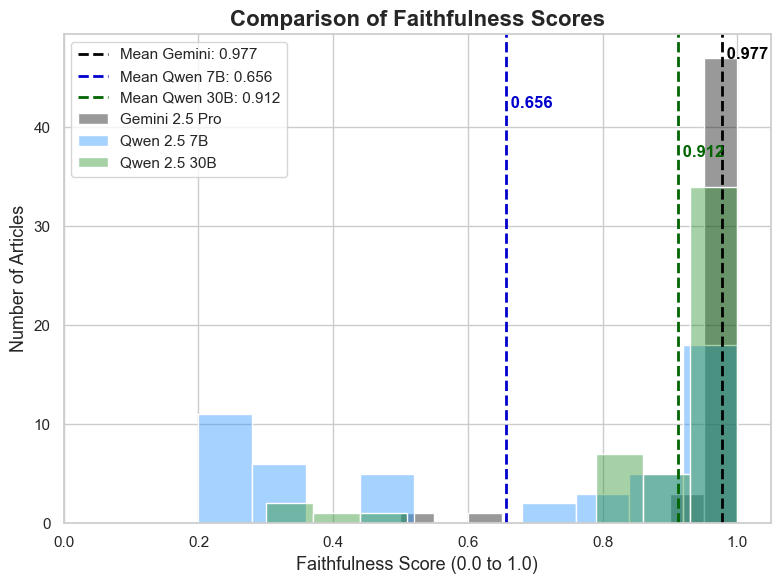

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка данных
df_gemini = pd.read_json("audit_gemini_faith_FINAL.json")
df_qwen = pd.read_json("audit_qwen7b.json")
df_qwen30b = pd.read_json("audit_qwen30b.json")

# 2. Расчет средних
mean_gemini = df_gemini['faithfulness_score'].mean()
mean_qwen = df_qwen['faithfulness_score'].mean()
mean_qwen30b = df_qwen30b['faithfulness_score'].mean() # Добавили расчет для 30b

# 3. Настройка стиля
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6)) # Немного увеличим ширину для наглядности

# 4. Построение распределения (Histogram)
sns.histplot(df_gemini['faithfulness_score'], label="Gemini 2.5 Pro", 
             color='black', alpha=0.4, bins=10)
sns.histplot(df_qwen['faithfulness_score'], label="Qwen 2.5 7B", 
             color='dodgerblue', alpha=0.4, bins=10)
sns.histplot(df_qwen30b['faithfulness_score'], label="Qwen 2.5 30B", 
             color='forestgreen', alpha=0.4, bins=10) # Добавили Qwen 30B

# 5. Добавление вертикальных линий среднего значения
plt.axvline(mean_gemini, color='black', linestyle='--', linewidth=2, 
            label=f'Mean Gemini: {mean_gemini:.3f}')
plt.axvline(mean_qwen, color='mediumblue', linestyle='--', linewidth=2, 
            label=f'Mean Qwen 7B: {mean_qwen:.3f}')
plt.axvline(mean_qwen30b, color='darkgreen', linestyle='--', linewidth=2, 
            label=f'Mean Qwen 30B: {mean_qwen30b:.3f}') # Добавили линию для 30B

# 6. Оформление осей и заголовков
plt.title('Comparison of Faithfulness Scores', fontsize=16, fontweight='bold')
plt.xlabel('Faithfulness Score (0.0 to 1.0)', fontsize=13)
plt.ylabel('Number of Articles', fontsize=13)
plt.xlim(0, 1.05) 
plt.legend(fontsize=11, loc='upper left')

# Добавляем текстовые аннотации
y_max = plt.ylim()[1]
plt.text(mean_gemini, y_max * 0.95, f' {mean_gemini:.3f}', color='black', fontweight='bold')
plt.text(mean_qwen, y_max * 0.85, f' {mean_qwen:.3f}', color='mediumblue', fontweight='bold')
plt.text(mean_qwen30b, y_max * 0.75, f' {mean_qwen30b:.3f}', color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/5w/td1qssr102g_shnry7z0q4k00000gn/T/ipykernel_65048/604601859.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_all, x='Model', y='faithfulness_score', palette="muted", inner="quartile")


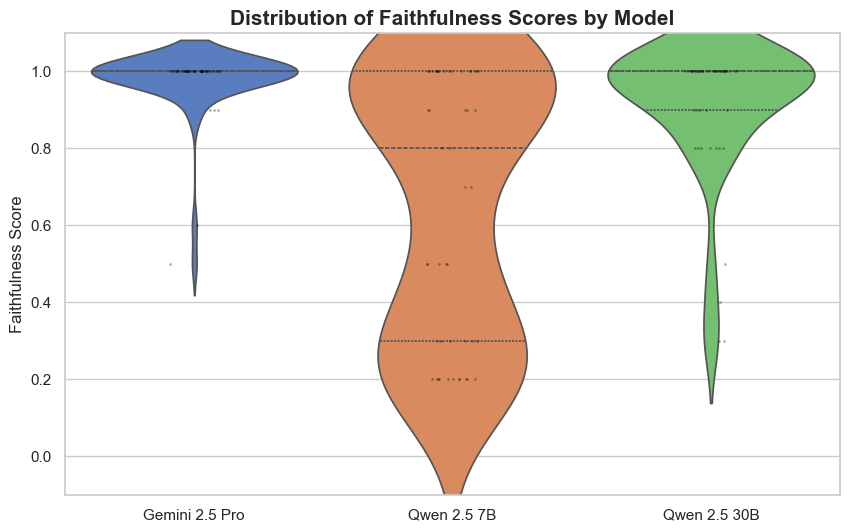

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Подготовка данных (переводим в "длинный" формат, удобный для seaborn)
df_gemini['Model'] = 'Gemini 2.5 Pro'
df_qwen['Model'] = 'Qwen 2.5 7B'
df_qwen30b['Model'] = 'Qwen 2.5 30B'

df_all = pd.concat([df_gemini, df_qwen, df_qwen30b])

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Рисуем скрипичный график
sns.violinplot(data=df_all, x='Model', y='faithfulness_score', palette="muted", inner="quartile")

# Добавляем точки (каждый отдельный результат), чтобы видеть плотность данных
sns.stripplot(data=df_all, x='Model', y='faithfulness_score', color="black", size=2, alpha=0.3)

plt.title('Distribution of Faithfulness Scores by Model', fontsize=15, fontweight='bold')
plt.ylabel('Faithfulness Score', fontsize=12)
plt.xlabel('')
plt.ylim(-0.1, 1.1)
plt.show()

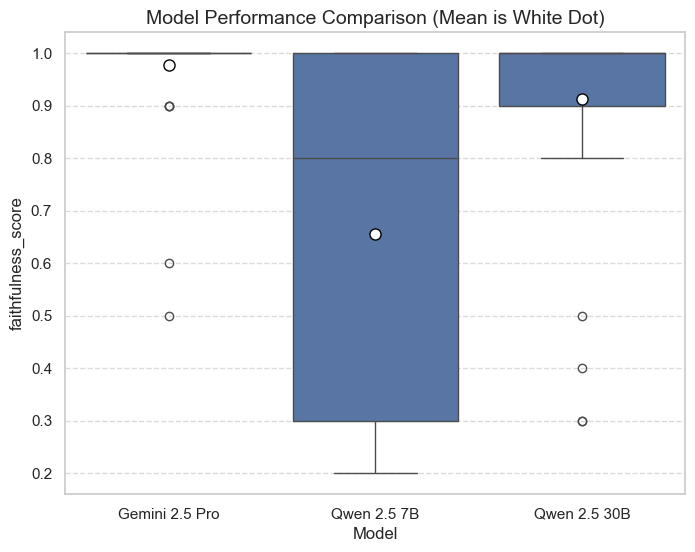

In [36]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_all, x='Model', y='faithfulness_score', 
            showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

plt.title('Model Performance Comparison (Mean is White Dot)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Figure size 1000x600 with 0 Axes>

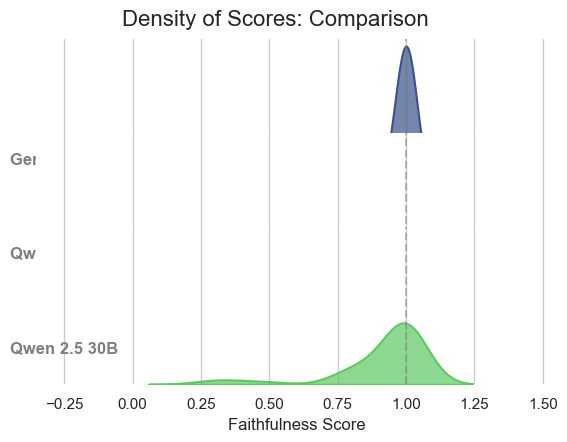

In [35]:
import seaborn as sns

# Используем тот же объединенный df_all из примера выше
plt.figure(figsize=(10, 6))

# Создаем FacetGrid для "хребтов"
g = sns.FacetGrid(df_all, row="Model", hue="Model", aspect=4, height=1.5, palette="viridis")

# Рисуем плотности
g.map(sns.kdeplot, "faithfulness_score", fill=True, alpha=0.7, lw=1.5)
g.map(plt.axvline, x=1.0, color='gray', linestyle='--', alpha=0.5) # Линия идеального результата

# Убираем лишние элементы оформления
g.set_titles("") 
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Добавляем названия моделей прямо на график
for i, ax in enumerate(g.axes.flat):
    ax.text(-0.05, 0.2, df_all['Model'].unique()[i], fontweight='bold', fontsize=12,
            color=ax.lines[0].get_color(), transform=ax.transAxes)

plt.subplots_adjust(hspace=-0.4) # Делаем графики слегка наложенными друг на друга
g.set_axis_labels("Faithfulness Score", "")
plt.suptitle("Density of Scores: Comparison", fontsize=16, y=0.98)
plt.show()

In [ ]:

# def evaluate_vs_gold(
#     candidate_json_path: str, 
#     gold_json_path: str, 
#     judge_model: str = "qwen/qwen3-235b-a22b-2507"
# ):
#     # 1. Загружаем данные
#     with open(candidate_json_path, "r", encoding="utf-8") as f:
#         candidates = {item['article_id']: item for item in json.load(f)}
    
#     with open(gold_json_path, "r", encoding="utf-8") as f:
#         golds = {item['article_id']: item for item in json.load(f)}

#     # 2. Настраиваем судью
#     judge_provider = OpenRouterProvider(api_key=os.getenv("OPENROUTER_API_KEY"), model_name=judge_model)
#     deepeval_judge = OpenRouterDeepEvalModel(judge_provider, judge_model)

#     # 3. Метрика: Сходство с эталоном (Alignment with Gold Standard)
#     # Здесь мы просим судью сравнить результат с идеалом
#     alignment_metric = GEval(
#         name="Summary Alignment",
#         criteria="""
#         Сравните 'Actual Output' (суммаризация тестируемой модели) с 'Expected Output' (эталонная суммаризация от экспертной модели).
#         Оцените, насколько полно тестируемая модель уловила те же ключевые научные факты, методологию и выводы, что и эталон.
#         Штрафуйте за пропуск важных сегментов, которые есть в эталоне, или за внесение противоречий.
#         """,
#         evaluation_params=[
#             LLMTestCaseParams.INPUT,           # Исходный текст
#             LLMTestCaseParams.ACTUAL_OUTPUT,    # То, что тестируем
#             LLMTestCaseParams.EXPECTED_OUTPUT   # Эталон Gemini
#         ],
#         model=deepeval_judge
#     )

#     results = []
    
#     # 4. Цикл оценки
#     for aid, cand_item in tqdm(candidates.items()):
#         if aid not in golds:
#             continue
            
#         gold_item = golds[aid]
        
#         # Создаем тест-кейс с эталоном
#         test_case = LLMTestCase(
#             input=str(cand_item['source_text']),
#             actual_output=cand_item['generated_summary'],
#             expected_output=gold_item['generated_summary'] # ВОТ ОН ЭТАЛОН
#         )

#         try:
#             alignment_metric.measure(test_case)
            
#             results.append({
#                 "article_id": aid,
#                 "score_vs_gemini": alignment_metric.score,
#                 "reason": alignment_metric.reason,
#                 "candidate_summary": cand_item['generated_summary'],
#                 "gemini_summary": gold_item['generated_summary']
#             })
#         except Exception as e:
#             print(f"Error evaluating {aid}: {e}")

#     # Сохраняем результат
#     df_eval = pd.DataFrame(results)
#     df_eval.to_json(f"eval_vs_gemini_{candidate_json_path}", orient="records", force_ascii=False, indent=2)
    
#     print(f"📊 Среднее сходство с Gemini: {df_eval['score_vs_gemini'].mean():.2f}")
#     return df_eval



# def evaluate_dataset(
#     input_json_path: str, 
#     judge_model: str = "qwen/qwen3-235b-a22b-2507",
#     output_eval_path: str = "evaluation_results.json"
# ):
#     """
#     Загружает датасет и проводит оценку G-Eval.
#     """
#     with open(input_json_path, "r", encoding="utf-8") as f:
#         data = json.load(f)

#     judge_provider = OpenRouterProvider(api_key=os.getenv("OPENROUTER_API_KEY"), model_name=judge_model)
#     deepeval_judge = OpenRouterDeepEvalModel(judge_provider, judge_model)

#     # Инициализация метрик
#     f_metric = GEval(
#         name="Faithfulness",
#         criteria="Summary must only contain facts supported by the input. Mark down for hallucinations.",
#         evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT],
#         model=deepeval_judge
#     )
    
#     r_metric = GEval(
#         name="Relevance",
#         criteria="Summary must capture key scientific findings and methodology, omitting trivial details.",
#         evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT],
#         model=deepeval_judge
#     )

#     sum_metric = SummarizationMetric(
#         threshold=0.5,
#         model=deepeval_judge,
#         assessment_questions=[
#             "Совпадают ли основные выводы с эталоном?",
#             "Нет ли в ответе фактов, противоречащих эталону?",
#             "Все ли ключевые термины из эталона присутствуют?"
#         ]
#     )
#     eval_results = []
#     print(f"⚖️ Начало оценки датасета {input_json_path} судьей {judge_model}...")

#     for item in tqdm(data):
#         # Подготовка исходного текста
#         src = item['source_text']
#         if isinstance(src, (dict, list)):
#             src_text = json.dumps(src)
#         else:
#             src_text = str(src)

#         test_case = LLMTestCase(
#             input=src_text,
#             actual_output=item['generated_summary']
#         )

#         try:
#             f_metric.measure(test_case)
#             r_metric.measure(test_case)

#             item.update({
#                 "score_faithfulness": f_metric.score,
#                 "reason_faithfulness": f_metric.reason,
#                 "score_relevance": r_metric.score,
#                 "reason_relevance": r_metric.reason,
#                 "judge_model": judge_model
#             })
#             eval_results.append(item)
#         except Exception as e:
#             print(f"Ошибка при оценке {item['article_id']}: {e}")

#     # Сохранение финальных результатов
#     df_res = pd.DataFrame(eval_results)
#     df_res.to_json(output_eval_path, orient="records", force_ascii=False, indent=2)
    
#     print(f"📊 Оценка завершена. Средняя верность: {df_res['score_faithfulness'].mean():.2f}")
#     return df_res